In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/zyang91/musa-practicum.git


Cloning into 'musa-practicum'...
remote: Enumerating objects: 279, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 279 (delta 1), reused 4 (delta 1), pack-reused 269 (from 2)
Receiving objects: 100% (279/279), 128.20 MiB | 33.19 MiB/s, done.
Resolving deltas: 100% (94/94), done.


In [3]:
%cd /content/musa-practicum/

/content/musa-practicum


In [4]:
!rm -rf data
!ln -s /content/drive/MyDrive/data data

!ls -l
!ls data

total 64
drwxr-xr-x 2 root root  4096 Apr  5 19:53 cache
lrwxrwxrwx 1 root root    27 Apr  5 19:53 data -> /content/drive/MyDrive/data
-rw-r--r-- 1 root root   655 Apr  5 19:53 final-visulization.md
-rw-r--r-- 1 root root 35149 Apr  5 19:53 LICENSE
-rw-r--r-- 1 root root  4835 Apr  5 19:53 README.md
drwxr-xr-x 6 root root  4096 Apr  5 19:53 result
drwxr-xr-x 5 root root  4096 Apr  5 19:53 scripts
drwxr-xr-x 2 root root  4096 Apr  5 19:53 shp
label  processed  raw_tiles  seg  vector


31680 31680 3
EPSG:2272


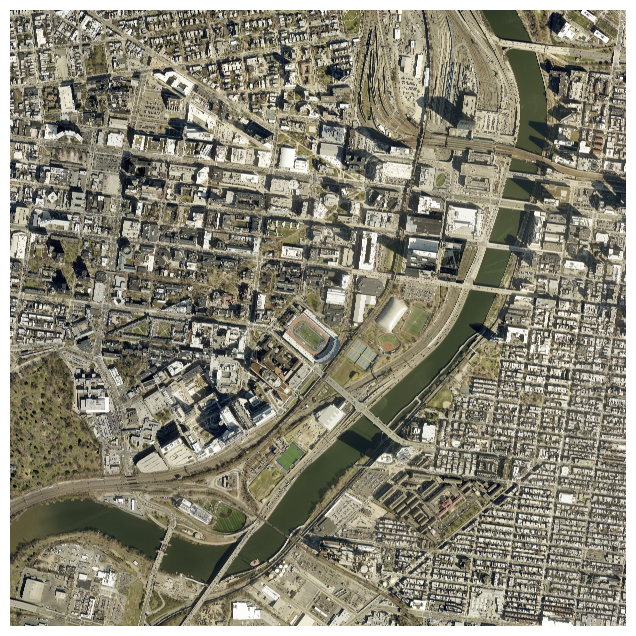

In [5]:
!pip -q install rasterio
import rasterio
import matplotlib.pyplot as plt

img_path = "data/processed/university_city_pilot_mosaic.tif"

with rasterio.open(img_path) as src:
    arr = src.read([1, 2, 3])
    print(src.width, src.height, src.count)
    print(src.crs)

plt.figure(figsize=(8, 8))
plt.imshow(arr.transpose(1, 2, 0))
plt.axis("off")
plt.show()

In [5]:
import os

paths = [
    "data/label/label.shp",
    "data/processed/university_city_pilot_mosaic.tif",
    "scripts/segementation/01_rasterize_labels.py",
    "scripts/segementation/03_make_patches.py",
    "scripts/segementation/05b_make_balanced_patch_subset.py",
    "scripts/segementation/05c_stratified_split.py",
    "scripts/segementation/06_train_unet.py",
    "scripts/segementation/07c_find_best_threshold.py",
]

for p in paths:
    print(p, "->", os.path.exists(p))


data/label/label.shp -> True
data/processed/university_city_pilot_mosaic.tif -> True
scripts/segementation/01_rasterize_labels.py -> True
scripts/segementation/03_make_patches.py -> True
scripts/segementation/05b_make_balanced_patch_subset.py -> True
scripts/segementation/05c_stratified_split.py -> True
scripts/segementation/06_train_unet.py -> True
scripts/segementation/07c_find_best_threshold.py -> True


In [6]:
!python scripts/segementation/01_rasterize_labels.py

Reference raster:
  CRS: EPSG:2272
  Shape: (31680, 31680)

Loaded labels: 202
Label CRS: EPSG:2272
Columns: ['label', 'geometry']

Saved mask to: data/seg/road_surface_mask.tif
Unique values in mask: [0 1]


In [7]:
!python scripts/segementation/03_make_patches.py

Saved total patches: 934
Saved positive patches: 521
Saved mostly empty patches: 413
Images dir: data/seg/images
Masks dir: data/seg/masks


In [8]:
!python scripts/segementation/05b_make_balanced_patch_subset.py

Found 934 image patches
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Positive patches: 451
Negative patches: 483
Selected total: 934
Balanced subset saved to:
data/patches_balanced/images
data/patches_balanced/masks


In [9]:
!python scripts/segementation/05c_stratified_split.py

Found 934 balanced image patches
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Train: 653
Val: 140
Test: 141
Done. Split saved to data/split/


In [10]:
from pathlib import Path

paths = [
    "data/split/train/images",
    "data/split/train/masks",
    "data/split/val/images",
    "data/split/val/masks",
    "data/split/test/images",
    "data/split/test/masks",
]

for p in paths:
    pp = Path(p)
    print(p, "exists:", pp.exists(), "count:", len(list(pp.glob("*"))) if pp.exists() else "missing")

data/split/train/images exists: True count: 653
data/split/train/masks exists: True count: 653
data/split/val/images exists: True count: 140
data/split/val/masks exists: True count: 140
data/split/test/images exists: True count: 141
data/split/test/masks exists: True count: 141


In [11]:
!nvidia-smi

Sun Apr  5 19:58:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   32C    P0             67W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [12]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [15]:
!python scripts/segementation/06_train_unet.py

Device: cuda
Train samples: 653
Val samples: 140
config.json: 100% 156/156 [00:00<00:00, 717kB/s]
model.safetensors: 100% 87.3M/87.3M [00:01<00:00, 85.4MB/s]

Epoch 1/25
Train:   0% 0/82 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Val:   0% 0/18 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sh

In [14]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.8 MB/s eta 0:00:00


In [16]:
!find . -type f \( -name "*.pth" -o -name "*.pt" -o -name "*.ckpt" \)

./models/best_unet.pt
./scripts/abandon/best_unet.pt


In [17]:
!mkdir -p "/content/drive/MyDrive/musa-practicum-models"
!cp "./models/best_unet.pt" "/content/drive/MyDrive/musa-practicum-models/"

In [18]:
!python scripts/segementation/07c_find_best_threshold.py

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Best threshold by F1:
threshold    0.400000
precision    0.924203
recall       0.955086
f1           0.939390
iou          0.885708
dice         0.939391
Name: 7, dtype: float64


In [19]:
!python scripts/segementation/08_visualize_predictions.py

Using device: cuda
Test samples: 141
Model path: models/best_unet.pt
Threshold: 0.4
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Saved: outputs/visualizations/sample_01_patch_00866.png
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Saved: outputs/visualizations/sample_02_patch_00573.png
Saved: outputs/visualizations/sample_03_patch_00929.png
Saved: outputs/visualizations/sample_04_patch_00085.png
Saved: outputs/visualizations/sample_05_patch_00428.png
Saved: outputs/visualizations/sample_06_patch_00121.png
Saved: outputs/visualizations/sample

In [20]:
!mkdir -p "/content/drive/MyDrive/musa-practicum-outputs"
!cp -r outputs/visualizations "/content/drive/MyDrive/musa-practicum-outputs/"

In [21]:
!rm -f outputs/full_scene/*.tif

In [22]:
!python scripts/segementation/09_full_scene_predict.py

Using device: cuda
Input raster: data/processed/university_city_pilot_mosaic.tif
Model path: models/best_unet.pt
Output dir: outputs/full_scene
Patch size: 256
Stride: 128
Threshold: 0.4
Raster size: 31680 x 31680
Total windows: 61009
Processed 100/61009 windows
Processed 200/61009 windows
Processed 300/61009 windows
Processed 400/61009 windows
Processed 500/61009 windows
Processed 600/61009 windows
Processed 700/61009 windows
Processed 800/61009 windows
Processed 900/61009 windows
Processed 1000/61009 windows
Processed 1100/61009 windows
Processed 1200/61009 windows
Processed 1300/61009 windows
Processed 1400/61009 windows
Processed 1500/61009 windows
Processed 1600/61009 windows
Processed 1700/61009 windows
Processed 1800/61009 windows
Processed 1900/61009 windows
Processed 2000/61009 windows
Processed 2100/61009 windows
Processed 2200/61009 windows
Processed 2300/61009 windows
Processed 2400/61009 windows
Processed 2500/61009 windows
Processed 2600/61009 windows
Processed 2700/61009

In [23]:
!mkdir -p "/content/drive/MyDrive/musa-practicum-outputs/full_scene"
!cp outputs/full_scene/* "/content/drive/MyDrive/musa-practicum-outputs/full_scene/"

In [24]:
!pip install -q scipy geopandas shapely fiona pyogrio

In [25]:
!python scripts/segementation/10_polygonize_and_clean.py

Original positive pixels: 4598286
Cleaned positive pixels: 4588914
Saved cleaned raster: outputs/vectorized/university_city_pilot_mosaic_bin_cleaned.tif
Polygon count: 756
Saved polygons: outputs/vectorized/university_city_pilot_mosaic_bin_polygons.gpkg
Saved polygons: outputs/vectorized/university_city_pilot_mosaic_bin_polygons.shp
Done.


In [29]:
!cp -r . /content/drive/MyDrive/musa-practicum_backup